## 本文概要
计算机视觉（CV）也是人工智能的一个重要分支，本文将构建模型使用torchvision中的数据集处理经典图片分类问题[FashionMNIST](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html)。

本文将继续使用[xx]()介绍的PyTorch工作流来处理图片分类问题。主要设计从torchvision库中加载数据及准备数据、线性模型和非线性模型及卷积模型处理CV问题的对比。

## PyTorch中的CV库
PyTorch中自带了许多计算机视觉相关的库和模型，具体介绍可参考[官网](https://docs.pytorch.org/vision/stable/index.html).
| PyTorch库| 功能简介 |
|:---|:---|
|torchvision|包含CV问题中的常见数据集、模型和图像变换|
|torchvision.datasets|提供许多CV数据集示例，包含图像分类、目标检测等问题，此外还提供了一系列用于穿件自定义数据集的类|
|torchvision.models|提供了用PyTorch实现的性能良好的CV模型|
|torchvision.transforms|主要用于图像在使用模型之前的转换（转为数字/处理/增强等）|
|torch.utils.data.Dataset|PyTorch的基础数据基类|
|torch.utils.data.DataLoader|创建一个基于数据集（使用torch.utils.data.Dataset）的Python可迭代对象|


## 使用PyTorch解决FashionMNIST问题
#### FashionMNIST介绍
FashionMNIST 是一个广泛用于测试机器学习算法的图像数据集，特别是在图像识别领域。它由 Zalando 发布，旨在替代传统的 MNIST 数据集，后者主要包含手写数字的图片。FashionMNIST 的设计初衷是提供一个稍微更具挑战性的问题，同时保持与原始 MNIST 数据集相同的图像大小（28x28 像素）和结构（训练集60,000张图片，测试集10,000张图片）。

![](./example-fashionmnist.png)

FashionMNIST 包含来自 10 个类别的服装和鞋类商品的灰度图像。这些类别包括：
1. T恤/上衣（T-shirt/top）
2. 裤子（Trouser）
3. 套头衫（Pullover）
4. 裙子（Dress）
5. 外套（Coat）
6. 凉鞋（Sandal）
7. 衬衫（Shirt）
8. 运动鞋（Sneaker）
9. 包（Bag）
10. 短靴（Ankle boot）

每个类别都有相同数量的图像，使得这个数据集成为一个平衡的数据集。这些图像的简单性和标准化尺寸使得 FashionMNIST 成为计算机视觉和机器学习领域入门级的理想选择。数据集被广泛用于教育和研究，用于测试各种图像识别方法的效果。下面我们将按照PyTorch的工作流来一步一步的构建模型解决FashionMNIST分类问题。

### 加载数据集

为了解决FashionMNIST问题，根据上一篇文章中PyTorch工作流，我们要先准备数据。前面我们提到过，torchvision.datasets中包含了很多CV的示例数据集，其中就包括FashionMNIST。下面我们直接写代码去加载示例数据集。

In [5]:
from torchvision import datasets
from torchvision.transforms import ToTensor
train_data = datasets.FashionMNIST(
    root="data",    #目录
    train=True,          #是否训练集
    download=True,       #是否下载到本地
    transform=ToTensor(), #转换为tensor，pytorch的模型只能处理tensor类型的输入
    target_transform=None)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor())


100%|██████████| 26.4M/26.4M [06:03<00:00, 72.6kB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 95.6kB/s]
100%|██████████| 4.42M/4.42M [00:25<00:00, 172kB/s] 
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.36MB/s]


上述代码会把数据集下载到本地指定的目录。我们可以查看数据集的相关信息。

In [12]:
# 查看第一个数据
image, label = train_data[0]
image, label, image.shape


(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [13]:
# 数据集的大小
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [14]:
# 分类的结果
train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

#### 使用DataLoader加载数据集
PyTorch 中，处理和加载数据是深度学习训练过程中的关键步骤。

为了高效地处理数据，PyTorch 提供了强大的工具，包括 torch.utils.data.Dataset 和 torch.utils.data.DataLoader，帮助我们管理数据集、批量加载和数据增强等任务。

PyTorch 数据处理与加载的介绍：

- 自定义 Dataset：通过继承 torch.utils.data.Dataset 来加载自己的数据集。
- DataLoader：DataLoader 按批次加载数据，支持多线程加载并进行数据打乱。
- 数据预处理与增强：使用 torchvision.transforms 进行常见的图像预处理和增强操作，提高模型的泛化能力。

DataLoader 是 PyTorch 提供的一个重要工具，用于从 Dataset 中按批次（batch）加载数据。

DataLoader 允许我们批量读取数据并进行多线程加载，从而提高训练效率。
##### 为什么要分批次加载数据
因为Batch处理可以减少每张图像的计算时间。
为啥可以减少呢？因为当你数据很多的时候，读取数据就会成为一个花费大量时间的事情，不如把更多的时间留在处理图片之上（一批批处理图像）。对于大多数机器学习问题来说，batch size设置为32是一个合适的选择。当然这是一个可设置的变量，可以尝试各种不同的值，不过一般最常用的是 2 的幂次（例如 32、64、128、256、512）。下面我们加载示例数据集。

In [17]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32

train_loader = DataLoader(train_data,batch_size = BATCH_SIZE, shuffle=True)
# shuffle=True表示每次迭代的时候都会打乱数据集的顺序，shuffle=False表示不打乱数据集的顺序。
test_loader = DataLoader(test_data,batch_size=BATCH_SIZE, shuffle=False)

# Let's check out what we've created
print(f"Dataloaders: {train_loader, test_loader}") 
print(f"Length of train dataloader: {len(train_loader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_loader)} batches of {BATCH_SIZE}")

# next(iter(train_loader))可以获取train_loader中的一个batch的数据，返回的是一个元组，包含两个元素，第一个元素是一个tensor，表示一个batch的特征数据，第二个元素是一个tensor，表示一个batch的标签数据。
train_features_batch, train_labels_batch = next(iter(train_loader))
train_features_batch.shape, train_labels_batch.shape

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x11668d2d0>, <torch.utils.data.dataloader.DataLoader object at 0x11668faf0>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


(torch.Size([32, 1, 28, 28]), torch.Size([32]))

#### 可视化数据集
数据集都是图片，可视化就是把图片打印出来

Image size: torch.Size([1, 28, 28])
Label: 9, label size: torch.Size([])


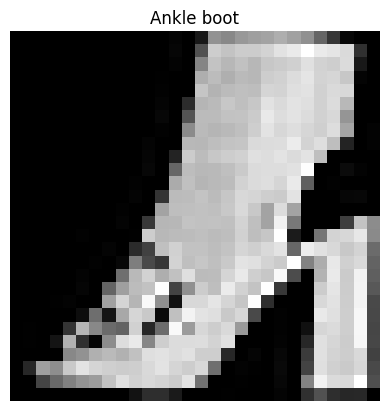

In [19]:
import matplotlib.pyplot as plt
# Show a sample
def show_sample():
    torch.manual_seed(42)
    random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
    img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(train_data.classes[label])
    plt.axis("Off");
    print(f"Image size: {img.shape}")
    print(f"Label: {label}, label size: {label.shape}")
    plt.show()

show_sample()

## 构建模型
我们将构建线性模型、非线性模型和卷积模型对这个分类问题进行处理，并对各模型的性能进行对比分析。
### 线性模型

In [20]:
from torch import nn
import torch
class FashionMnistModelV0(nn.Module):
    def __init__(self,input_shape : int, hidden_units : int, output_shape : int):
        super().__init__()
        self.layer_stack = nn.Sequential(nn.Flatten(),
                                           nn.Linear(in_features=input_shape, out_features=hidden_units),
                                           nn.Linear(in_features=hidden_units,out_features=output_shape))
    def forward(self, x : torch.Tensor):
        return self.layer_stack(x)

model_0 = FashionMnistModelV0(input_shape=784, hidden_units=10, output_shape=len(train_data.classes))
model_0.to("cpu")
model_0, model_0.state_dict()

(FashionMnistModelV0(
   (layer_stack): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=784, out_features=10, bias=True)
     (2): Linear(in_features=10, out_features=10, bias=True)
   )
 ),
 OrderedDict([('layer_stack.1.weight',
               tensor([[ 0.0296, -0.0084,  0.0328,  ...,  0.0093,  0.0135, -0.0188],
                       [-0.0354,  0.0187,  0.0085,  ..., -0.0001,  0.0115, -0.0008],
                       [ 0.0017,  0.0045,  0.0133,  ..., -0.0188,  0.0059,  0.0100],
                       ...,
                       [ 0.0273, -0.0344,  0.0127,  ...,  0.0283, -0.0011, -0.0230],
                       [ 0.0257,  0.0291,  0.0243,  ..., -0.0087,  0.0001,  0.0176],
                       [-0.0147,  0.0053, -0.0194,  ..., -0.0221,  0.0205, -0.0093]])),
              ('layer_stack.1.bias',
               tensor([ 0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,  0.0018,
                        0.0163,  0.0069])),
              ('l

### 非线性模型

与线性模型不同，非线性模型的关键在于引入了激活函数，从而让网络具备学习复杂模式的能力。这里我们使用的 `FashionMnistModelV1` 由两层线性层组成，中间插入了一个 ReLU 激活函数。

它的结构可以理解为：

1. `Flatten`：把输入图像从二维矩阵展开为一维向量，尺寸从 $28 \times 28$ 变成 $784$。
2. `Linear`：第一个全连接层把 $784$ 维特征映射到隐藏层。
3. `ReLU`：激活函数，给模型引入非线性能力，让它不仅仅是简单的线性变换。
4. `Linear`：第二个全连接层把隐藏层输出映射到 10 个分类结果。
5. `ReLU`：在输出前再一次引入非线性，帮助模型捕捉更复杂的特征关系。

ReLU（Rectified Linear Unit）是深度学习中最常见的激活函数之一，其公式为：

$$
\text{ReLU}(x) = \max(0, x)
$$

也就是说，当输入大于 0 时，直接输出原值；当输入小于 0 时，输出为 0。它的优点是计算简单、收敛速度快，并且在很多视觉任务中表现良好。相比于 Sigmoid 等激活函数，ReLU 能更有效地缓解梯度消失问题，因此在深度学习中被广泛使用。

通过在两层线性层之间加入 ReLU，模型就能够学习到比纯线性模型更复杂的映射关系，从而更适合处理 FashionMNIST 这类图像分类任务。

In [21]:
class FashionMnistModelV1(nn.Module):
    def __init__(self,input_shape : int, hidden_units : int, output_shape : int):
        super().__init__()
        self.layer_stack = nn.Sequential(nn.Flatten(),
                                           nn.Linear(in_features=input_shape, out_features=hidden_units),
                                           nn.ReLU(),
                                           nn.Linear(in_features=hidden_units,out_features=output_shape),
                                           nn.ReLU())
    def forward(self, x : torch.Tensor):
        return self.layer_stack(x)
    
model_1 = FashionMnistModelV1(input_shape=784, hidden_units=10,output_shape=len(train_data.classes))
model_1.to("cpu")
model_1, model_1.state_dict()

(FashionMnistModelV1(
   (layer_stack): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=784, out_features=10, bias=True)
     (2): ReLU()
     (3): Linear(in_features=10, out_features=10, bias=True)
     (4): ReLU()
   )
 ),
 OrderedDict([('layer_stack.1.weight',
               tensor([[ 0.0224, -0.0181,  0.0197,  ...,  0.0355, -0.0293, -0.0290],
                       [ 0.0062,  0.0239,  0.0236,  ...,  0.0102, -0.0129,  0.0235],
                       [ 0.0318,  0.0348, -0.0320,  ..., -0.0323, -0.0270, -0.0275],
                       ...,
                       [-0.0201,  0.0322, -0.0096,  ..., -0.0022,  0.0090,  0.0300],
                       [ 0.0132,  0.0252,  0.0189,  ...,  0.0141, -0.0189, -0.0134],
                       [ 0.0170, -0.0218,  0.0071,  ...,  0.0029, -0.0044,  0.0155]])),
              ('layer_stack.1.bias',
               tensor([-0.0296,  0.0081, -0.0277,  0.0282, -0.0141,  0.0073,  0.0024, -0.0142,
                       -0.0

### 卷积模型

卷积神经网络（CNN）是计算机视觉领域最常用的模型之一。与前面的线性模型和非线性模型相比，卷积模型不仅能够处理图片中的像素信息，还能够自动学习局部特征，比如边缘、纹理和形状。

这里的 `FashionMnistModelV2` 主要由两部分组成：

1. 卷积块（Convolutional Blocks）
   - `Conv2d`：卷积层，用来从输入图像中提取局部特征。
   - `ReLU`：为卷积层输出引入非线性能力，增强模型表达能力。
   - `MaxPool2d`：池化层，用来下采样，减少特征图大小，降低计算成本，同时保留最重要的信息。

2. 分类头（Classifier）
   - `Flatten`：把卷积层提取到的二维特征图展开为一维向量。
   - `Linear`：把展开后的特征送入全连接层，进行最终分类。

卷积层是 CNN 的核心。它通过一个小的卷积核在输入图像上滑动，逐局部地提取特征。相比于普通全连接层，卷积层具有三个重要优势：

- 参数共享：同一个卷积核在整张图上共享权重，能显著减少参数量。
- 局部感知：每个卷积核只关注局部区域，更适合学习图像中的空间结构。
- 平移不变性：即使目标在图像中的位置发生轻微变化，模型也能更稳定地识别它。

在这里，第一层卷积层会先提取基础边缘和纹理特征，后续卷积层再进一步组合这些局部信息，形成更高层次的特征表示。最后通过分类层把这些特征映射到 10 个类别上，完成 FashionMNIST 的分类任务。


In [22]:
class FashionMnistModelV2(nn.Module):
    def __init__(self, input_shape : int, hidden_units : int, output_shape : int):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3,padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units,hidden_units,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,out_features=output_shape)
        )
    def forward(self, x : torch.Tensor):
        x = self.block1(x)
        x = self.block2(x)
        return self.classifier(x)

model_2 = FashionMnistModelV2(input_shape=1, hidden_units=10, output_shape=len(train_data.classes))
model_2.to("cpu")
model_2, model_2.state_dict()

(FashionMnistModelV2(
   (block1): Sequential(
     (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (3): ReLU()
     (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (block2): Sequential(
     (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (3): ReLU()
     (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (classifier): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=490, out_features=10, bias=True)
   )
 ),
 OrderedDict([('block1.0.weight',
               tensor([[[[-0.2442,  0.0819,  0.2525],
                         [-0.3209, -0.0882,  0.2841],
                         [ 0.2413, -0.2224,  0.2667]]],
               
               
    

## 训练模型

在训练模型的这一步中，我们真正开始让神经网络“学习”。与传统机器学习不同，深度学习并不是一次性把所有数据丢给模型，而是通过多轮迭代，反复比较模型预测结果和真实标签，逐步调整参数，让损失函数越来越小。

接下来我们会看到几个关键函数，它们共同构成了完整的训练流程：

- `train_step`：这是训练过程的核心函数。它会从 DataLoader 中取出一个 batch 的数据，先进行前向传播得到预测结果，再计算损失值，随后通过反向传播计算梯度，最后由优化器更新模型参数。
- `test_step`：训练完成后，我们需要在测试集上评估模型表现。这个函数会关闭梯度计算，并在验证阶段统计损失和准确率，帮助我们观察模型是否真正学到了可泛化的特征。
- `accuracy_fn`：用于计算分类任务中的准确率。它会把模型输出的类别概率转成预测类别，再和真实标签做比较，得到当前 batch 的正确率。
- `train_test_model`：这是整个训练流程的总控函数。它负责设置随机种子、创建优化器、定义训练轮数 epoch，并循环调用训练和测试函数，完成完整的训练过程。
- `print_train_time`：用于统计整个训练过程耗费的时间。它会记录训练开始和结束时刻，然后计算总耗时，方便我们比较不同模型、不同超参数下的训练效率。

这里还涉及几个重要的深度学习概念：

- Batch：一次喂给模型的一小批样本，通常是 32、64 或 128 张图片。
- Epoch：遍历完整训练集一次，称为一个 epoch。训练通常需要多个 epoch，模型会在每个 epoch 中持续学习和微调。
- Loss：损失函数，用来衡量模型预测和真实标签之间的差距。
- Optimizer：优化器，例如 SGD 或 Adam，会根据梯度更新模型参数。
- Backpropagation：反向传播，是神经网络中最核心的学习机制之一。
- `model.eval()`：在测试阶段使用，告诉模型当前处于评估模式，某些层（如 Dropout、BatchNorm）会切换到推理行为。
- `tqdm`：一个常用于可视化训练进度的 Python 库。它会在循环运行时显示进度条，让我们更直观地看到当前训练到了第几个 epoch、已经完成了多少轮迭代，尤其适合训练时间较长的深度学习任务。

此外，这里用到了 Python 的 `timeit` 模块中的 `default_timer`。它可以高精度地测量代码的执行时间，适合用来测试训练过程的耗时，帮助我们评估模型训练效率和优化效果。

通过这几个函数的组合，我们就能把“准备数据 → 定义模型 → 训练模型 → 评估效果”完整串联起来。

In [24]:
from timeit import default_timer as timer
from tqdm.auto import tqdm
#
device = "cuda" if torch.cuda.is_available() else "cpu"

def print_train_time(start:float, end : float, device:torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: total time{total_time:.3f} seconds")
    return total_time

# 训练
def train_step(
        model:torch.nn.Module,
        data_loader:torch.utils.data.DataLoader,
        loss_fn:torch.nn.Module,
        optimizer:torch.optim.Optimizer,
        accuracy_fn,
        device:torch.device = device):
    train_loss, train_acc = 0,0
    model.to(device)
    for batch, (X,y) in enumerate(data_loader):
        X,y = X.to(device), y.to(device)
        y_pred = model(X)

        loss=loss_fn(y_pred,y)
        train_loss += loss

        train_acc += accuracy_fn(y_true=y, y_pred = y_pred.argmax(dim=1))

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()
    
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"train loss:{train_loss:.5f} | train_acc:{train_acc:.5f}")

# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

def test_step(data_loader:torch.utils.data.DataLoader,
              model:torch.nn.Module,
              loss_fn:torch.nn.Module,
              accuracy_fn,
              device:torch.device=device):
    test_loss, test_acc = 0,0
    model.to(device)
    model.eval()

    with torch.inference_mode():
        for X,y in data_loader:
            X,y = X.to(device), y.to(device)
            test_pred = model(X)

            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y, y_pred = test_pred.argmax(dim=1))

        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"test loss:{test_loss:.5f} | test acc:{test_acc:.5f}")

def train_test_model(model:torch.nn.Module):
    loss_fn = nn.CrossEntropyLoss()
    torch.manual_seed(42)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    start_time = timer()
    epochs = 3

    for epoch in tqdm(range(epochs)):
        print(f"model:{model.__class__.__name__}, epoch:{epoch}\n-------")
        train_step(model, train_loader, loss_fn, optimizer, accuracy_fn)

        test_step(test_loader,model,loss_fn, accuracy_fn)
    end_time = timer()

    total_train_time = print_train_time(start_time, end_time, device= device)


### 训练线性模型

线性模型结构最简单，训练速度通常最快，因为它只包含少量全连接层和参数。但是它的表达能力最弱，模型只能学习输入特征的线性组合，因此在 FashionMNIST 这种图像分类任务上，准确率通常低于非线性模型和卷积模型。

In [25]:
train_test_model(model_0)

  0%|          | 0/3 [00:00<?, ?it/s]

model:FashionMnistModelV0, epoch:0
-------
train loss:0.59484 | train_acc:78.99000
test loss:0.51635 | test acc:81.83906
model:FashionMnistModelV0, epoch:1
-------
train loss:0.47946 | train_acc:83.12333
test loss:0.48138 | test acc:83.17692
model:FashionMnistModelV0, epoch:2
-------
train loss:0.45703 | train_acc:83.99000
test loss:0.47773 | test acc:83.49641
Train time on cpu: total time3.625 seconds


### 训练非线性模型

非线性模型加入了 ReLU 激活函数，因此比线性模型能学习更复杂的特征关系。训练时间会比线性模型稍长一些，因为网络中多了非线性运算，但相比卷积模型仍然更轻量。

In [26]:
train_test_model(model_1)

  0%|          | 0/3 [00:00<?, ?it/s]

model:FashionMnistModelV1, epoch:0
-------
train loss:0.86889 | train_acc:69.37667
test loss:0.76598 | test acc:72.10463
model:FashionMnistModelV1, epoch:1
-------
train loss:0.71478 | train_acc:73.91000
test loss:0.72002 | test acc:73.60224
model:FashionMnistModelV1, epoch:2
-------
train loss:0.49891 | train_acc:82.34167
test loss:0.49107 | test acc:82.77756
Train time on cpu: total time3.648 seconds


### 训练卷机模型

卷积模型具有更强的特征提取能力，尤其擅长图像数据。相比前面两个模型，它的训练时间通常更长，因为卷积计算和多层特征图处理需要更多计算量。但是它的数据利用效率更高，通常能获得更好的测试准确率。

In [27]:
train_test_model(model_2)

  0%|          | 0/3 [00:00<?, ?it/s]

model:FashionMnistModelV2, epoch:0
-------
train loss:0.59909 | train_acc:78.41667
test loss:0.38515 | test acc:86.07228
model:FashionMnistModelV2, epoch:1
-------
train loss:0.35397 | train_acc:87.44333
test loss:0.34276 | test acc:87.91933
model:FashionMnistModelV2, epoch:2
-------
train loss:0.31553 | train_acc:88.74333
test loss:0.32489 | test acc:88.49840
Train time on cpu: total time43.885 seconds


## 测试模型

测试模型的过程主要包含三个部分：

1. 从测试集中随机选取少量样本，作为可视化展示的预测对象；
2. 将这些样本送入训练好的模型进行前向推理，得到预测概率和最终类别；
3. 将预测结果与真实标签进行对比，并通过可视化图像展示模型是否正确识别。

在本 notebook 中，`get_test_data()` 会固定随机种子，选取 9 张测试图像；`make_predictions()` 会对这 9 张图片逐一进行推理，并输出每张图片对应的预测概率分布；`plot_pred()` 则将图片与预测结果、真实标签一起画成网格图，正确的预测用绿色标题标注，错误的预测用红色标题标注。

这种可视化方式有几个好处：

- 直观观察模型对单张图片的预测行为；
- 能发现常见的误判类型，比如某些类别容易混淆；
- 便于对比不同模型在同一组样本上的表现。

在后面的对比中，`model_1` 是非线性全连接模型，`model_2` 是卷积模型。通常情况下，`model_1` 能比纯线性模型获得更好的识别效果，但它依然缺乏卷积模型在图像特征提取上的优势；`model_2` 可以更好地捕捉局部纹理和形状信息，因此在同一组测试样本上，往往会给出更准确的分类结果。

因此，这一节不仅测试模型的最终预测性能，也通过可视化对比展示了两种不同模型结构在 FashionMNIST 任务中的差异。

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 5 (Sandal)
tensor([[4.7466e-05, 4.7466e-05, 4.7466e-05, 4.7466e-05, 4.7466e-05, 5.9282e-01,
         4.7466e-05, 2.1299e-02, 4.7466e-05, 3.8555e-01],
        [6.5452e-02, 2.4692e-02, 5.3494e-03, 8.7780e-01, 2.1754e-02, 1.3885e-04,
         4.4012e-03, 1.3885e-04, 1.3885e-04, 1.3885e-04]])
tensor([5, 3, 7, 4, 3, 0, 4, 7, 1])


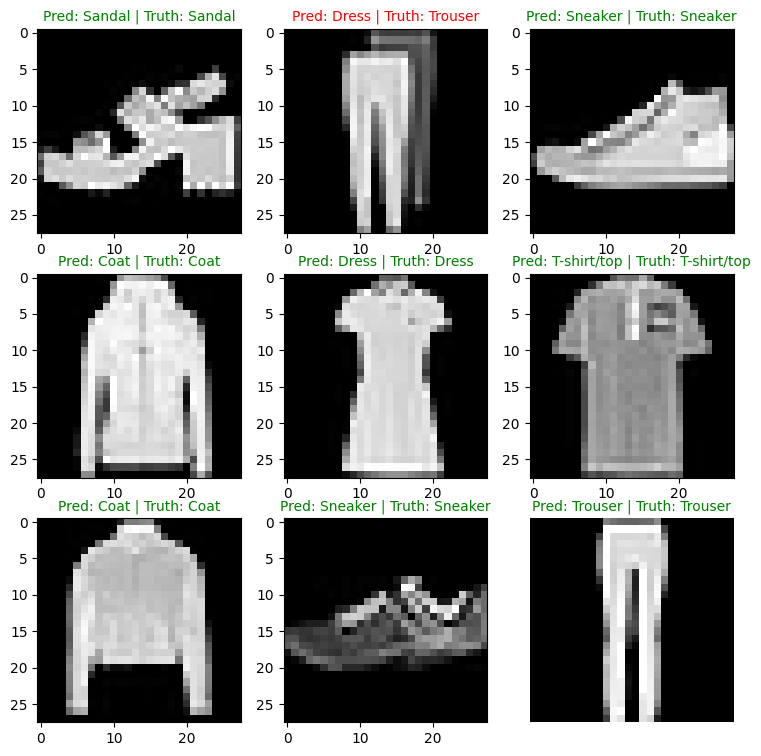

In [30]:
import random
def get_test_data():
    random.seed(42)
    test_sample = []
    test_label = []

    for sample, label in random.sample(list(test_data), k=9):
        test_sample.append(sample)
        test_label.append(label)
    print(f"Test sample image shape: {test_sample[0].shape}\nTest sample label: {test_label[0]} ({train_data.classes[test_label[0]]})")

    return test_sample, test_label

def make_predictions(
        model:torch.nn.Module,
        data:list,
        device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            #print(f"before: {sample.shape}")
            sample = torch.unsqueeze(sample, dim=0).to(device)

            pred_logits = model(sample)

            pred_prob = torch.softmax(pred_logits.squeeze(), dim=0)

            #print(f"after: {sample.shape},logits:{pred_logits.shape}, pred_prob:{pred_prob.shape}")

            pred_probs.append(pred_prob)
    return torch.stack(pred_probs)

def plot_pred(test_sample, test_label, pred_class):
    # Plot predictions
    plt.figure(figsize=(9, 9))
    nrows = 3
    ncols = 3
    for i, sample in enumerate(test_sample):
        # Create a subplot
        plt.subplot(nrows, ncols, i+1)

        # Plot the target image
        plt.imshow(sample.squeeze(), cmap="gray")

        # Find the prediction label (in text form, e.g. "Sandal")
        pred_label = train_data.classes[pred_class[i]]

        # Get the truth label (in text form, e.g. "T-shirt")
        truth_label = train_data.classes[test_label[i]] 

        # Create the title text of the plot
        title_text = f"Pred: {pred_label} | Truth: {truth_label}"
        
        # Check for equality and change title colour accordingly
        if pred_label == truth_label:
            plt.title(title_text, fontsize=10, c="g") # green text if correct
        else:
            plt.title(title_text, fontsize=10, c="r") # red text if wrong
    plt.axis(False);
    plt.show()

test_sample, test_label = get_test_data()
# 测试模型1
pred_probs = make_predictions(model_1, test_sample)
print(pred_probs[:2])
pred_class = pred_probs.argmax(dim=1)
print(pred_class)
plot_pred(test_sample, test_label, pred_class)

tensor([[3.4413e-07, 3.0474e-08, 1.5013e-08, 1.2193e-08, 1.0592e-07, 9.9958e-01,
         3.5144e-06, 4.3372e-07, 4.7673e-06, 4.0997e-04],
        [1.3820e-02, 9.2217e-01, 2.8096e-05, 2.8358e-02, 1.7744e-02, 5.4622e-05,
         1.6938e-02, 4.8836e-04, 3.9951e-05, 3.5842e-04]])
tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])


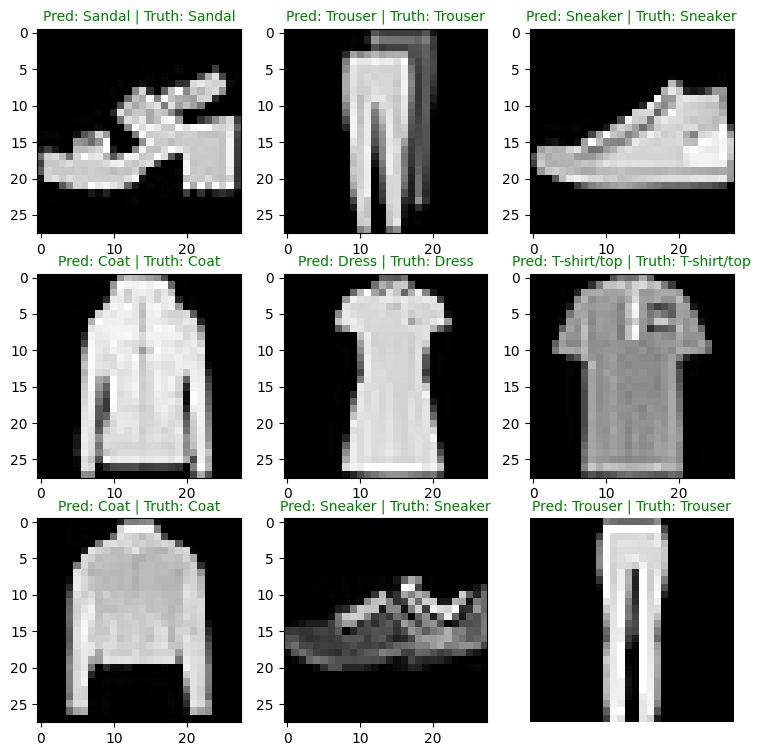

In [31]:
# 测试模型2
pred_probs = make_predictions(model_2, test_sample)
print(pred_probs[:2])
pred_class = pred_probs.argmax(dim=1)
print(pred_class)
plot_pred(test_sample, test_label, pred_class)